## Ejercicio 3: Agente de inspección de calidad de productos

### Ficha PEAS
| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | `dimensiones_ok` (True/False), `peso_ok` (True/False), `defectos_visuales` (conteo) |
| **Acciones (A)** | Aprobado, Reinspección, Rechazado |
| **Entorno (E)** | Línea de ensamblaje e inspección de calidad industrial |
| **Objetivo** | Garantizar el cumplimiento de estándares de calidad antes del empaquetado final |
| **Medida de desempeño (P)** | Tasa de precisión en la detección de defectos y reducción de falsos positivos |

### Justificación de las reglas
Un producto que cumple las dimensiones y el peso sin presentar defectos se aprueba automáticamente. Si existen fallas menores de dimensión o peso pero sin defectos visuales graves, pasa a reinspección manual para no desechar piezas recuperables. Si presenta múltiples defectos o fallas críticas combinadas, se rechaza directamente.

In [2]:
def agente_inspeccion(dimensiones_ok, peso_ok, defectos_visuales):
    if dimensiones_ok and peso_ok and defectos_visuales == 0:
        return (
            "Aprobado",
            "Cumple al 100% con los estándares de dimensión, peso y acabado.",
        )
    elif (not dimensiones_ok or not peso_ok) and defectos_visuales <= 1:
        return (
            "Reinspección",
            "Desviación menor en peso/medida; requiere evaluación manual.",
        )
    else:
        return (
            "Rechazado",
            "Falla crítica en métricas clave o presencia excesiva de defectos.",
        )

In [3]:
lote_productos = [
    (True, True, 0, "Pieza A1"),
    (True, False, 1, "Pieza B2"),
    (False, True, 0, "Pieza C3"),
    (False, False, 3, "Pieza D4"),
    (True, True, 2, "Pieza E5"),
]

print("--- RESULTADOS DE INSPECCIÓN DE CALIDAD ---")
for dim, peso, defs, nombre in lote_productos:
    estado, mot = agente_inspeccion(dim, peso, defs)
    print(f"Producto [{nombre}] -> Estado: {estado} | Motivo: {mot}")

--- RESULTADOS DE INSPECCIÓN DE CALIDAD ---
Producto [Pieza A1] -> Estado: Aprobado | Motivo: Cumple al 100% con los estándares de dimensión, peso y acabado.
Producto [Pieza B2] -> Estado: Reinspección | Motivo: Desviación menor en peso/medida; requiere evaluación manual.
Producto [Pieza C3] -> Estado: Reinspección | Motivo: Desviación menor en peso/medida; requiere evaluación manual.
Producto [Pieza D4] -> Estado: Rechazado | Motivo: Falla crítica en métricas clave o presencia excesiva de defectos.
Producto [Pieza E5] -> Estado: Rechazado | Motivo: Falla crítica en métricas clave o presencia excesiva de defectos.


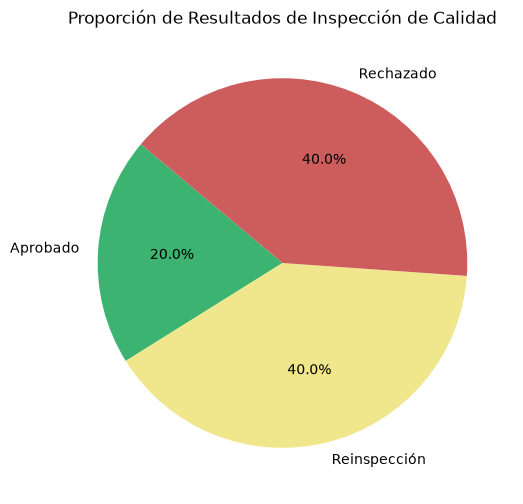

In [4]:
import matplotlib.pyplot as plt

estados = [
    agente_inspeccion(dim, peso, defs)[0]
    for dim, peso, defs, _ in lote_productos
]
conteo = {
    e: estados.count(e) for e in ["Aprobado", "Reinspección", "Rechazado"]
}

plt.figure(figsize=(6, 6))
plt.pie(
    conteo.values(),
    labels=conteo.keys(),
    autopct="%1.1f%%",
    colors=["mediumseagreen", "khaki", "indianred"],
    startangle=140,
)
plt.title("Proporción de Resultados de Inspección de Calidad")
plt.show()